In [1]:
from pathlib import Path
from torch import multiprocessing
from tqdm import tqdm
import soundfile as sf

In [2]:
import numpy as np
import pandas as pd
import time

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib import colors
import datetime as dt

In [4]:
import sys

# append the path of the
# parent directory
sys.path.append('..')
sys.path.append('../src/')
sys.path.append('../src/models/bat_call_detector/batdetect2/')

import src.batdt2_pipeline as batdetect2_pipeline
from pipeline import pipeline
from utils.utils import gen_empty_df
from cfg import get_config

In [5]:
def run_models(file_mappings):
    """
    Runs the batdetect2 model to detect bat search-phase calls in the provided audio segments and saves detections into a .csv.

    Parameters
    ------------
    file_mappings : `List`
        - List of dictionaries generated by initialize_mappings()

    Returns
    ------------
    bd_dets : `pandas.DataFrame`
        - A DataFrame of detections that will also be saved in the provided output_dir under the above csv_name
        - 7 columns in this DataFrame: start_time, end_time, low_freq, high_freq, detection_confidence, event, input_file
        - Detections are always specified w.r.t their input_file; earliest start_time can be 0 and latest end_time can be 1795.
        - Events are always "Echolocation" as we are using a model that only detects search-phase calls.
    """

    bd_dets = pd.DataFrame()
    for i in tqdm(range(len(file_mappings))):
        cur_seg = file_mappings[i]
        bd_annotations_df = cur_seg['model']._run_batdetect(cur_seg['audio_seg']['audio_file'])
        bd_offsetted = pipeline._correct_annotation_offsets(
                bd_annotations_df,
                cur_seg['original_file_name'],
                cur_seg['audio_seg']['offset']
            )
        bd_dets = pd.concat([bd_dets, bd_offsetted])
        
    return bd_dets

def apply_models(file_path_mappings, cfg):
    """
    Runs the batdetect2 model to detect bat search-phase calls in the provided audio segments and saves detections into a dataframe

    Parameters
    ------------
    file_mappings : `List`
        - List of dictionaries generated by initialize_mappings()
    cfg : `dict`
        - A dictionary of pipeline parameters:
        - models is the models in the pipeline that are being used.

    Returns
    ------------
    bd_preds : `pandas.DataFrame`
        - A DataFrame of detections that will also be saved in the provided output_dir under the above csv_name
        - 7 columns in this DataFrame: start_time, end_time, low_freq, high_freq, detection_confidence, event, input_file
        - Detections are always specified w.r.t their input_file; earliest start_time can be 0 and latest end_time can be 1795.
        - Events are always "Echolocation" as we are using a model that only detects search-phase calls.
    """

    process_pool = multiprocessing.Pool(cfg['num_processes'])

    bd_dets = tqdm(
            process_pool.imap(apply_model, file_path_mappings, chunksize=1), 
            desc=f"Applying BatDetect2",
            total=len(file_path_mappings),
        )
    
    bd_preds = gen_empty_df() 
    bd_preds = pd.concat(bd_dets, ignore_index=True)
    
    return bd_preds

def apply_model(file_mapping):
    """
    Runs the batdetect2 model on a single provided audio segmens and corrects the offsets according the segment.

    Parameters
    ------------
    file_mappings : `List`
        - List of dictionaries generated by initialize_mappings()

    Returns
    ------------
    corrected_bd_dets : `pandas.DataFrame`
        - A DataFrame of detections that will also be saved in the provided output_dir under the above csv_name
        - 7 columns in this DataFrame: start_time, end_time, low_freq, high_freq, detection_confidence, event, input_file
        - Detections are always specified w.r.t their input_file; earliest start_time can be 0 and latest end_time can be 1795.
        - Events are always "Echolocation" as we are using a model that only detects search-phase calls.
    """

    print(f"Processing {file_mapping['audio_seg']['audio_file']}")
    bd_dets = file_mapping['model']._run_batdetect(file_mapping['audio_seg']['audio_file'])
    corrected_bd_dets = pipeline._correct_annotation_offsets(
                                                            bd_dets,
                                                            file_mapping['original_file_name'],
                                                            file_mapping['audio_seg']['offset']
                                                            )

    return corrected_bd_dets

In [6]:
def run_pipeline_on_file(file, cfg):
    bd_preds = pd.DataFrame()

    if not cfg['output_dir'].is_dir():
        cfg['output_dir'].mkdir(parents=True, exist_ok=True)
    if not cfg['tmp_dir'].is_dir():
        cfg['tmp_dir'].mkdir(parents=True, exist_ok=True)

    cfg["csv_filename"] = f"batdetect2_pipeline_{file.name.split('.')[0]}"
    print(f"Generating detections for {file.name}")
    segmented_file_paths = batdetect2_pipeline.generate_segmented_paths([file], cfg)
    file_path_mappings = batdetect2_pipeline.initialize_mappings(segmented_file_paths, cfg)
    bd_preds = run_models(file_path_mappings)
    if cfg['save']:
        batdetect2_pipeline._save_predictions(bd_preds, cfg['output_dir'], cfg)
    batdetect2_pipeline.delete_segments(segmented_file_paths)

    return bd_preds

def apply_pipeline_on_file(file, cfg):
    bd_preds = pd.DataFrame()

    if not cfg['output_dir'].is_dir():
        cfg['output_dir'].mkdir(parents=True, exist_ok=True)
    if not cfg['tmp_dir'].is_dir():
        cfg['tmp_dir'].mkdir(parents=True, exist_ok=True)

    cfg["csv_filename"] = f"batdetect2_pipeline_{file.name.split('.')[0]}"
    print(f"Generating detections for {file.name}")
    segmented_file_paths = batdetect2_pipeline.generate_segmented_paths([file], cfg)
    file_path_mappings = batdetect2_pipeline.initialize_mappings(segmented_file_paths, cfg)
    bd_preds = apply_models(file_path_mappings, cfg)
    if cfg['save']:
        batdetect2_pipeline._save_predictions(bd_preds, cfg['output_dir'], cfg)
    batdetect2_pipeline.delete_segments(segmented_file_paths)

    return bd_preds

In [9]:
input_file = Path('../../Downloads/recover-20220728/Carp/20220728_080000.WAV')

cfg = get_config()
cfg['input_audio'] = input_file
cfg['tmp_dir'] = Path('../output')
cfg['output_dir'] = Path('../output_dir')
cfg['num_processes'] = 2
cfg['should_csv'] = False
cfg['save'] = True

run_pipeline_on_file(input_file, cfg)

Generating detections for 20220728_080000.WAV


100%|██████████| 60/60 [06:09<00:00,  6.16s/it]


,start_time,end_time,low_freq,high_freq,class,class_prob,det_prob,individual,event,input_file
0,5.8035,5.8132,37500,43789,Pipistrellus nathusii,0.459,0.577,-1,Echolocation,../../Downloads/recover-20220728/Carp/20220728...
1,6.1035,6.1126,37500,47445,Pipistrellus nathusii,0.378,0.538,-1,Echolocation,../../Downloads/recover-20220728/Carp/20220728...
2,6.2085,6.2189,37500,46328,Pipistrellus nathusii,0.405,0.536,-1,Echolocation,../../Downloads/recover-20220728/Carp/20220728...
3,6.4205,6.4304,37500,44472,Pipistrellus nathusii,0.482,0.611,-1,Echolocation,../../Downloads/recover-20220728/Carp/20220728...
4,6.5275,6.5377,36640,47744,Pipistrellus nathusii,0.450,0.591,-1,Echolocation,../../Downloads/recover-20220728/Carp/20220728...
...,...,...,...,...,...,...,...,...,...,...
86,1794.1435,1794.1580,22890,29234,Nyctalus leisleri,0.488,0.648,-1,Echolocation,../../Downloads/recover-20220728/Carp/20220728...
87,1794.3755,1794.3911,22890,27858,Nyctalus leisleri,0.565,0.629,-1,Echolocation,../../Downloads/recover-20220728/Carp/20220728...
88,1794.6075,1794.6260,22890,27947,Nyctalus leisleri,0.361,0.540,-1,Echolocation,../../Downloads/recover-20220728/Carp/20220728...
89,1794.7165,1794.7290,25468,29839,Nyctalus leisleri,0.611,0.676,-1,Echolocation,../../Downloads/recover-20220728/Carp/20220728...


In [7]:
input_file = Path('../../Downloads/recover-20220728/Carp/20220728_080000.WAV')

cfg = get_config()
cfg['segment_duration'] = 30.0
cfg['input_audio'] = input_file
cfg['tmp_dir'] = Path('../output')
cfg['output_dir'] = Path('../output_dir')
cfg['run_model'] = True
cfg['num_processes'] = 4
cfg['should_csv'] = False
cfg['save'] = True

# apply_pipeline_on_file(input_file, cfg)
bd_preds = pd.DataFrame()

if not cfg['output_dir'].is_dir():
    cfg['output_dir'].mkdir(parents=True, exist_ok=True)
if not cfg['tmp_dir'].is_dir():
    cfg['tmp_dir'].mkdir(parents=True, exist_ok=True)

cfg["csv_filename"] = f"batdetect2_pipeline_{input_file.name.split('.')[0]}"
print(f"Generating detections for {input_file.name}")
segmented_file_paths = batdetect2_pipeline.generate_segmented_paths([input_file], cfg)
file_path_mappings = batdetect2_pipeline.initialize_mappings(segmented_file_paths, cfg)
file_path_mappings[:2]

Generating detections for 20220728_080000.WAV


[{'audio_seg': {'input_filepath': PosixPath('../../Downloads/recover-20220728/Carp/20220728_080000.WAV'),
   'audio_file': PosixPath('../output/20220728_080000__0.00_30.00.wav'),
   'offset': 0.0},
  'model': <models.bat_call_detector.model_detector.BatCallDetector at 0x77165b06b0d0>,
  'original_file_name': PosixPath('../../Downloads/recover-20220728/Carp/20220728_080000.WAV')},
 {'audio_seg': {'input_filepath': PosixPath('../../Downloads/recover-20220728/Carp/20220728_080000.WAV'),
   'audio_file': PosixPath('../output/20220728_080000__30.00_60.00.wav'),
   'offset': 30.0},
  'model': <models.bat_call_detector.model_detector.BatCallDetector at 0x77165b06b0d0>,
  'original_file_name': PosixPath('../../Downloads/recover-20220728/Carp/20220728_080000.WAV')}]

In [8]:
input = file_path_mappings[:]

In [ ]:
time_taken = np.zeros(4)
num_processes = 4
chunksizes = np.array([10, 15, 30, 60])
for i in np.arange(0, 4, 1):
    pool = multiprocessing.Pool(processes=num_processes)
    chunks_per_processor = chunksizes[i]
    print(f'Parsing {len(input)} chunks with {num_processes} processors and {chunks_per_processor} chunks per processor')
    start = time.time()
    results = tqdm(pool.imap(apply_model, input, chunksize=chunks_per_processor), 
                    desc=f"Applying BatDetect2", total=len(input),)
    bd_preds = gen_empty_df() 
    bd_preds = pd.concat(results, ignore_index=True)
    end = time.time()
    print(f'Time taken: {end-start}s')
    time_taken[i] = end-start

time_taken

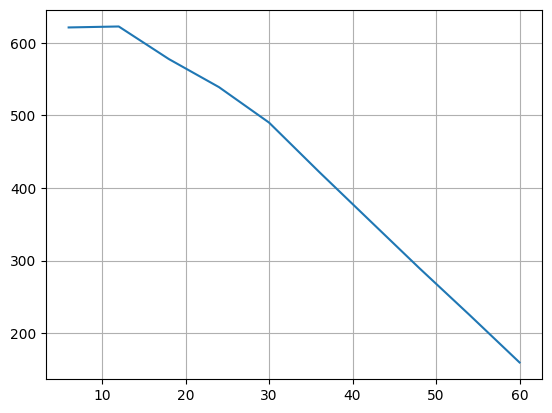

In [ ]:
plt.plot(chunksizes, time_taken)
plt.grid(which='both')
plt.show()

In [9]:
input = file_path_mappings[:4]

In [10]:
time_taken_test2 = np.zeros(4)
for i in np.arange(1, 4+1):
    num_processes = 2
    pool = multiprocessing.Pool(processes=num_processes)
    chunks_per_processor = i
    print(f'Parsing {len(input)} chunks with {num_processes} processors and {chunks_per_processor} chunks per processor')
    start = time.time()
    results = tqdm(pool.imap(apply_model, input, chunksize=chunks_per_processor), 
                    desc=f"Applying BatDetect2", total=len(input),)
    bd_preds = gen_empty_df() 
    bd_preds = pd.concat(results, ignore_index=True)
    end = time.time()
    print(f'Time taken: {end-start}s')
    time_taken_test2[i-1] = end-start

time_taken_test2

Parsing 4 chunks with 2 processors and 1 chunks per processor


Applying BatDetect2:   0%|          | 0/4 [00:00<?, ?it/s]

Processing ../output/20220728_080000__30.00_60.00.wavProcessing ../output/20220728_080000__0.00_30.00.wav



Applying BatDetect2:  25%|██▌       | 1/4 [00:13<00:41, 13.71s/it]

Processing ../output/20220728_080000__60.00_90.00.wav
Processing ../output/20220728_080000__90.00_120.00.wav


...

Applying BatDetect2:   0%|          | 0/4 [00:00<?, ?it/s]

Processing ../output/20220728_080000__0.00_30.00.wav
Processing ../output/20220728_080000__30.00_60.00.wav
Processing ../output/20220728_080000__60.00_90.00.wav
Processing ../output/20220728_080000__90.00_120.00.wav


Applying BatDetect2: 100%|██████████| 4/4 [00:24<00:00,  6.17s/it]

Time taken: 24.683651447296143s


array([28.2330327 , 31.16379476, 26.27659321, 24.68365145])

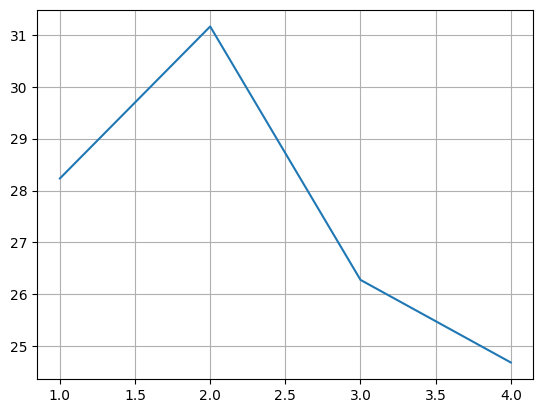

In [12]:
plt.plot(np.arange(1,5,1, dtype=int), time_taken_test2)
plt.grid(which='both')
plt.show()

In [13]:
input = file_path_mappings[:10]

In [14]:
num_processes = 1
pool = multiprocessing.Pool(processes=num_processes)
chunksize_default, extra = divmod(len(input), num_processes*4)
if extra:
    chunksize_default += 1
chunksize_custom = 10
(f'Parsing {len(input)} chunks with {num_processes} processors and {chunksize_custom} chunks per processor')

'Parsing 10 chunks with 1 processors and 10 chunks per processor'

In [15]:
time_taken_test3 = np.zeros(multiprocessing.cpu_count())
for i in np.arange(multiprocessing.cpu_count()):
    num_processes = i+1
    pool = multiprocessing.Pool(processes=num_processes)
    chunksize_custom = 10
    print(f'Parsing {len(input)} chunks with {num_processes} processors and {chunksize_custom} chunks per processor')
    start = time.time()
    results = tqdm(pool.imap(apply_model, input, chunksize=chunksize_custom), 
                    desc=f"Applying BatDetect2", total=len(input),)
    bd_preds = gen_empty_df() 
    bd_preds = pd.concat(results, ignore_index=True)
    end = time.time()
    print(f'Time taken: {end-start}s')
    time_taken_test3[i] = end-start
time_taken_test3

Parsing 10 chunks with 1 processors and 10 chunks per processor


Applying BatDetect2:   0%|          | 0/10 [00:00<?, ?it/s]

Processing ../output/20220728_080000__0.00_30.00.wav


Processing ../output/20220728_080000__30.00_60.00.wav
Processing ../output/20220728_080000__60.00_90.00.wav
Processing ../output/20220728_080000__90.00_120.00.wav
Processing ../output/20220728_080000__120.00_150.00.wav
Processing ../output/20220728_080000__150.00_180.00.wav
Processing ../output/20220728_080000__180.00_210.00.wav
Processing ../output/20220728_080000__210.00_240.00.wav
Processing ../output/20220728_080000__240.00_270.00.wav
Processing ../output/20220728_080000__270.00_300.00.wav


Applying BatDetect2: 100%|██████████| 10/10 [01:00<00:00,  6.03s/it]

...

Applying BatDetect2:   0%|          | 0/10 [00:00<?, ?it/s]

Processing ../output/20220728_080000__0.00_30.00.wav
Processing ../output/20220728_080000__30.00_60.00.wav
Processing ../output/20220728_080000__60.00_90.00.wav
Processing ../output/20220728_080000__90.00_120.00.wav
Processing ../output/20220728_080000__120.00_150.00.wav
Processing ../output/20220728_080000__150.00_180.00.wav
Processing ../output/20220728_080000__180.00_210.00.wav
Processing ../output/20220728_080000__210.00_240.00.wav
Processing ../output/20220728_080000__240.00_270.00.wav
Processing ../output/20220728_080000__270.00_300.00.wav


Applying BatDetect2: 100%|██████████| 10/10 [00:59<00:00,  5.99s/it]

Time taken: 59.878178119659424s


array([60.29955935, 59.87817812])

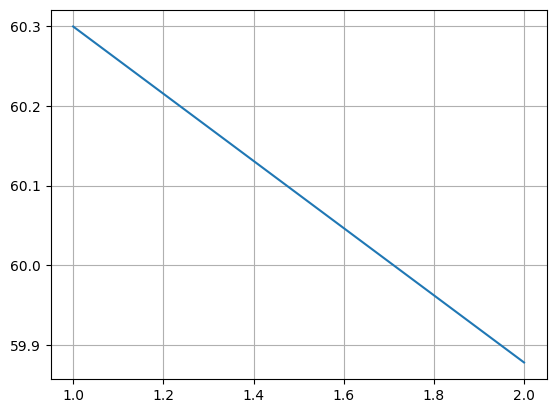

In [16]:
plt.plot(1+np.arange(multiprocessing.cpu_count(), dtype=int), time_taken_test3)
plt.grid(which='both')
plt.show()

In [17]:
input = file_path_mappings[:2]
num_processes = 2
pool = multiprocessing.Pool(processes=num_processes)
chunksize_custom = 2
print(f'Parsing {len(input)} chunks with {num_processes} processors and {chunksize_custom} chunks per processor')
start = time.time()
results = tqdm(pool.imap(apply_model, input, chunksize=chunksize_custom), 
                desc=f"Applying BatDetect2", total=len(input),)
bd_preds = gen_empty_df() 
bd_preds = pd.concat(results, ignore_index=True)
end = time.time()
print(f'Time taken: {end-start}s')

Parsing 2 chunks with 2 processors and 2 chunks per processor


Applying BatDetect2:   0%|          | 0/2 [00:00<?, ?it/s]

Processing ../output/20220728_080000__0.00_30.00.wav


Processing ../output/20220728_080000__30.00_60.00.wav


Applying BatDetect2: 100%|██████████| 2/2 [00:12<00:00,  6.29s/it]

Time taken: 12.585386037826538s


In [18]:
input = file_path_mappings[:1]
time_taken_test3 = np.zeros(multiprocessing.cpu_count())
for i in np.arange(multiprocessing.cpu_count()):
    num_processes = i+1
    pool = multiprocessing.Pool(processes=num_processes)
    chunksize_custom = 1
    print(f'Parsing {len(input)} chunks with {num_processes} processors and {chunksize_custom} chunks per processor')
    start = time.time()
    results = tqdm(pool.imap(apply_model, input, chunksize=chunksize_custom), 
                    desc=f"Applying BatDetect2", total=len(input),)
    bd_preds = gen_empty_df() 
    bd_preds = pd.concat(results, ignore_index=True)
    end = time.time()
    print(f'Time taken: {end-start}s')
    time_taken_test3[i] = end-start
time_taken_test3

Parsing 1 chunks with 1 processors and 1 chunks per processor


Applying BatDetect2:   0%|          | 0/1 [00:00<?, ?it/s]

Processing ../output/20220728_080000__0.00_30.00.wav


Applying BatDetect2: 100%|██████████| 1/1 [00:06<00:00,  6.52s/it]

Time taken: 6.521106958389282s


...

Applying BatDetect2:   0%|          | 0/1 [00:00<?, ?it/s]

Processing ../output/20220728_080000__0.00_30.00.wav


Applying BatDetect2: 100%|██████████| 1/1 [00:06<00:00,  6.59s/it]

Time taken: 6.594871759414673s


array([6.52110696, 6.59487176])

In [8]:
start = time.time()
run_models(file_path_mappings[:8])
end = time.time()
print(f'Baseline time {end-start}s')

100%|██████████| 8/8 [00:48<00:00,  6.02s/it]


Baseline time 48.15837049484253s
Parsing 8 chunks with 1 processors and 1 chunks per processor
Processing ../output/20220728_080000__0.00_30.00.wav


In [8]:
input = file_path_mappings[:8]
time_taken_test3 = np.zeros((multiprocessing.cpu_count(), len(input)))
for i in np.arange(multiprocessing.cpu_count()):
    num_processes = i+1
    pool = multiprocessing.Pool(processes=num_processes)
    for j in np.arange(len(input)):
        chunksize_custom = int(j+1)
        print(f'Parsing {len(input)} chunks with {num_processes} processors and {chunksize_custom} chunks per processor')
        start = time.time()
        results = tqdm(pool.imap(apply_model, input, chunksize=chunksize_custom), 
                        desc=f"Applying BatDetect2", total=len(input),)
        bd_preds = gen_empty_df() 
        bd_preds = pd.concat(results, ignore_index=True)
        end = time.time()
        # print(f'Time taken: {end-start}s')
        time_taken_test3[i,j] = end-start
        print(time_taken_test3)

Parsing 8 chunks with 1 processors and 1 chunks per processor


Applying BatDetect2:   0%|          | 0/8 [00:00<?, ?it/s]

Processing ../output/20220728_080000__0.00_30.00.wav


Applying BatDetect2:  12%|█▎        | 1/8 [00:06<00:44,  6.31s/it]

Processing ../output/20220728_080000__30.00_60.00.wav


...

[[48.46583581 48.0206058  48.10078549 48.13431549 47.93809915 47.03399014
  47.82981467 47.81163096]
 [58.83239365 58.41434264 55.35987926 57.79904985 55.57254338 53.05996633
  48.13338208  0.        ]]
Parsing 8 chunks with 2 processors and 8 chunks per processor
Processing ../output/20220728_080000__0.00_30.00.wav


Applying BatDetect2:   0%|          | 0/8 [00:00<?, ?it/s]

Processing ../output/20220728_080000__30.00_60.00.wav
Processing ../output/20220728_080000__60.00_90.00.wav
Processing ../output/20220728_080000__90.00_120.00.wav
Processing ../output/20220728_080000__120.00_150.00.wav
Processing ../output/20220728_080000__150.00_180.00.wav
Processing ../output/20220728_080000__180.00_210.00.wav
Processing ../output/20220728_080000__210.00_240.00.wav


Applying BatDetect2: 100%|██████████| 8/8 [00:46<00:00,  5.87s/it]

[[48.46583581 48.0206058  48.10078549 48.13431549 47.93809915 47.03399014
  47.82981467 47.81163096]
 [58.83239365 58.41434264 55.35987926 57.79904985 55.57254338 53.05996633
  48.13338208 46.94722319]]


In [9]:
time_taken_test3

array([[48.46583581, 48.0206058 , 48.10078549, 48.13431549, 47.93809915,
        47.03399014, 47.82981467, 47.81163096],
       [58.83239365, 58.41434264, 55.35987926, 57.79904985, 55.57254338,
        53.05996633, 48.13338208, 46.94722319]])

In [ ]:
start = time.time()
run_models(file_path_mappings[:4])
end = time.time()
print(f'Baseline time {end-start}s')

100%|██████████| 4/4 [00:23<00:00,  5.92s/it]


Baseline time 23.69948387145996s
Parsing 4 chunks with 1 processors and 1 chunks per processor
Processing ../output/20220728_080000__0.00_30.00.wav


In [8]:
input = file_path_mappings[:4]
time_taken_test4 = np.zeros((multiprocessing.cpu_count(), len(input)))
for i in np.arange(multiprocessing.cpu_count()):
    num_processes = int(i+1)
    pool = multiprocessing.Pool(processes=num_processes)
    for j in np.arange(len(input)):
        chunksize_custom = int(j+1)
        print(f'Parsing {len(input)} chunks with {num_processes} processors and {chunksize_custom} chunks per processor')
        start = time.time()
        results = (pool.map(apply_model, input, chunksize=chunksize_custom))
        bd_preds = gen_empty_df() 
        bd_preds = pd.concat(results, ignore_index=True)
        end = time.time()
        # print(f'Time taken: {end-start}s')
        time_taken_test4[i,j] = end-start
        print(time_taken_test4)

Processing ../output/20220728_080000__0.00_30.00.wav


Parsing 4 chunks with 1 processors and 1 chunks per processor
Processing ../output/20220728_080000__30.00_60.00.wav
Processing ../output/20220728_080000__60.00_90.00.wav
Processing ../output/20220728_080000__90.00_120.00.wav
[[23.86920571  0.          0.          0.        ]
 [ 0.          0.          0.          0.        ]]
Parsing 4 chunks with 1 processors and 2 chunks per processor
Processing ../output/20220728_080000__0.00_30.00.wav
Processing ../output/20220728_080000__30.00_60.00.wav
Processing ../output/20220728_080000__60.00_90.00.wav
Processing ../output/20220728_080000__90.00_120.00.wav
[[23.86920571 23.53513312  0.          0.        ]
 [ 0.          0.          0.          0.        ]]
Parsing 4 chunks with 1 processors and 3 chunks per processor
Processing ../output/20220728_080000__0.00_30.00.wav
Processing ../output/20220728_080000__30.00_60.00.wav
Processing ../output/20220728_080000__60.00_90.00.wav
Processing ../output/20220728_080000__90.00_120.00.wav
[[23.86920571

In [9]:
time_taken_test4

array([[23.86920571, 23.53513312, 23.6751709 , 23.64064908],
       [30.26761746, 28.89480233, 26.97720885, 23.17019272]])

In [7]:
input_file = Path('../../Downloads/recover-20220728/Carp/20220728_080000.WAV')

cfg = get_config()
cfg['segment_duration'] = 60.0
cfg['input_audio'] = input_file
cfg['tmp_dir'] = Path('../output')
cfg['output_dir'] = Path('../output_dir')
cfg['run_model'] = True
cfg['num_processes'] = 4
cfg['should_csv'] = False
cfg['save'] = True

# apply_pipeline_on_file(input_file, cfg)
bd_preds = pd.DataFrame()

if not cfg['output_dir'].is_dir():
    cfg['output_dir'].mkdir(parents=True, exist_ok=True)
if not cfg['tmp_dir'].is_dir():
    cfg['tmp_dir'].mkdir(parents=True, exist_ok=True)

cfg["csv_filename"] = f"batdetect2_pipeline_{input_file.name.split('.')[0]}"
print(f"Generating detections for {input_file.name}")
segmented_file_paths = batdetect2_pipeline.generate_segmented_paths([input_file], cfg)
file_path_mappings = batdetect2_pipeline.initialize_mappings(segmented_file_paths, cfg)
file_path_mappings[:2]

Generating detections for 20220728_080000.WAV


[{'audio_seg': {'input_filepath': PosixPath('../../Downloads/recover-20220728/Carp/20220728_080000.WAV'),
   'audio_file': PosixPath('../output/20220728_080000__0.00_60.00.wav'),
   'offset': 0.0},
  'model': <models.bat_call_detector.model_detector.BatCallDetector at 0x78e0e3d5d0d0>,
  'original_file_name': PosixPath('../../Downloads/recover-20220728/Carp/20220728_080000.WAV')},
 {'audio_seg': {'input_filepath': PosixPath('../../Downloads/recover-20220728/Carp/20220728_080000.WAV'),
   'audio_file': PosixPath('../output/20220728_080000__60.00_120.00.wav'),
   'offset': 60.0},
  'model': <models.bat_call_detector.model_detector.BatCallDetector at 0x78e0e3d5d0d0>,
  'original_file_name': PosixPath('../../Downloads/recover-20220728/Carp/20220728_080000.WAV')}]

In [12]:
start = time.time()
run_models(file_path_mappings[:4])
end = time.time()
print(f'Baseline time {end-start}s')

100%|██████████| 4/4 [00:47<00:00, 11.86s/it]


In [8]:
input = file_path_mappings[:4]
time_taken_test5 = np.zeros((4, len(input)))
for i in np.arange(4):
    for j in np.arange(len(input)):
        num_processes = int(i+1)
        pool = multiprocessing.Pool(processes=num_processes)
        chunksize_custom = int(j+1)
        print(f'Parsing {len(input)} chunks with {num_processes} processors and {chunksize_custom} chunks per processor')
        start = time.time()
        results = (pool.map(apply_model, input, chunksize=chunksize_custom))
        bd_preds = gen_empty_df() 
        bd_preds = pd.concat(results, ignore_index=True)
        end = time.time()
        # print(f'Time taken: {end-start}s')
        time_taken_test5[i,j] = end-start
        print(time_taken_test5)

Processing ../output/20220728_080000__0.00_60.00.wav


Parsing 4 chunks with 1 processors and 1 chunks per processor
Processing ../output/20220728_080000__60.00_120.00.wav
Processing ../output/20220728_080000__120.00_180.00.wav
Processing ../output/20220728_080000__180.00_240.00.wav
[[47.91932225  0.          0.          0.        ]
 [ 0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.        ]]
Processing ../output/20220728_080000__0.00_60.00.wav
Parsing 4 chunks with 1 processors and 2 chunks per processor
Processing ../output/20220728_080000__60.00_120.00.wav
Processing ../output/20220728_080000__120.00_180.00.wav
Processing ../output/20220728_080000__180.00_240.00.wav
[[47.91932225 47.23703289  0.          0.        ]
 [ 0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.        ]]
Processing ../output/20220728_080000__0.00_60.00.wav
Parsing 4 chunks with 1 pr

In [9]:
time_taken_test5

array([[47.91932225, 47.23703289, 48.79374385, 48.96452641],
       [59.89311862, 59.75924754, 53.33359957, 46.39480543],
       [54.0384872 , 60.55121851, 54.03352284, 47.68750691],
       [57.98692298, 60.28886437, 54.3708868 , 47.76777363]])